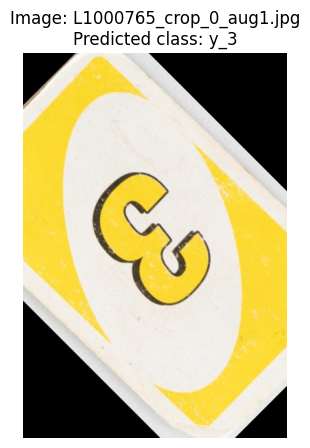

Predicted class: y_3


In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models

# Paths
PROJECT = r"C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project"
MODEL_PATH = os.path.join(PROJECT, "card_classifier.pth")
CLASSES_PATH = os.path.join(PROJECT, "label_classes.npy")
AUG_DIR = os.path.join(PROJECT, "aug")

# Load class names
classes = np.load(CLASSES_PATH, allow_pickle=True)
num_classes = len(classes)

# Build model architecture and load weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

# Inference transform (same as validation)
infer_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Pick one augmented image
aug_images = sorted([
    f for f in os.listdir(AUG_DIR)
    if f.lower().endswith(".jpg")
])
if len(aug_images) == 0:
    raise FileNotFoundError(f"No .jpg files found in {AUG_DIR}")

img_name = aug_images[0]
img_path = os.path.join(AUG_DIR, img_name)
img = Image.open(img_path).convert("RGB")

# Predict
x = infer_tf(img).unsqueeze(0).to(device)
with torch.no_grad():
    logits = model(x)
    pred_idx = int(torch.argmax(logits, dim=1).item())

pred_class = str(classes[pred_idx])

# Display image and prediction
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Image: {img_name}\nPredicted class: {pred_class}")
plt.axis("off")
plt.show()

print(f"Predicted class: {pred_class}")